In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import casadi as ca

DATA_PATH =  "/Users/berger/fzj/cadet/CADET-Live/Experiments/PioReactor/yeast_2Days/export_20250921082017"

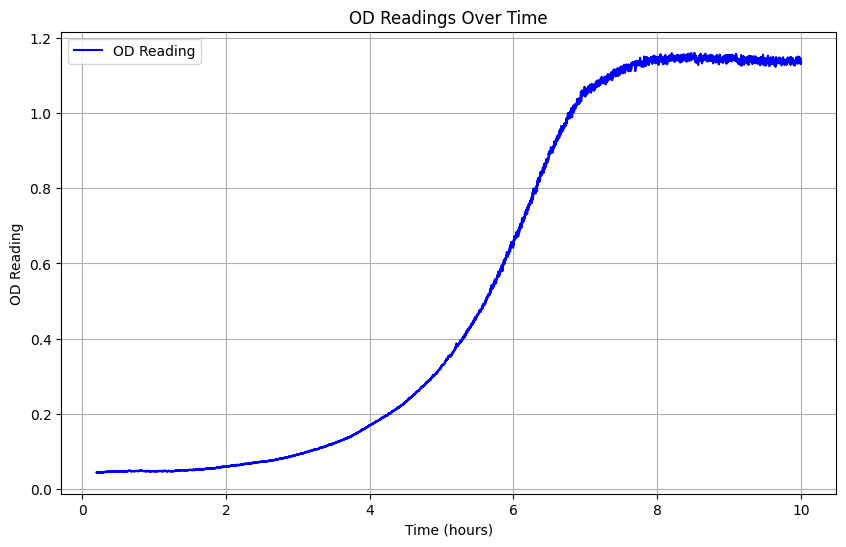

In [ ]:
df_od_readings = pd.read_csv(f"{DATA_PATH}/od_readings/od_readings-Yeast_Grow_4_Days-all_units-20250921102018.csv")
first_10_hours = df_od_readings[df_od_readings['hours_since_experiment_created'] <= 10]

plt.figure(figsize=(10, 6))
plt.plot(first_10_hours['hours_since_experiment_created'], first_10_hours['od_reading'], label='OD Reading', color='blue')
plt.xlabel('Time (hours)')
plt.ylabel('OD Reading')
plt.title('OD Readings Over Time')
plt.legend()
plt.grid()
plt.show()

In [20]:
X = ca.MX.sym('X')   # Biomass [g/L]
S = ca.MX.sym('S')   # Glucose [g/L]
E = ca.MX.sym('E')   # Ethanol [g/L]

eps = 1e-8

S_pos = ca.fmax(S, eps)
E_pos = ca.fmax(E, eps)
X_pos = ca.fmax(X, eps)

x = ca.vertcat(X, S, E)

mu_S_max = ca.MX.sym('mu_S_max')
mu_E_max = ca.MX.sym('mu_E_max')
K_S      = ca.MX.sym('K_S')
K_E      = ca.MX.sym('K_E')
K_I      = ca.MX.sym('K_I')
Y_XS     = ca.MX.sym('Y_XS')
Y_ES     = ca.MX.sym('Y_ES')
Y_XE     = ca.MX.sym('Y_XE')

p = ca.vertcat(mu_S_max, mu_E_max, K_S, K_E, K_I, Y_XS, Y_ES, Y_XE)

eps = 1e-8

mu_S = mu_S_max * S_pos / (K_S + S_pos + eps)
glc_rep = K_I / (K_I + S_pos + eps)
mu_E = mu_E_max * E_pos / (K_E + E_pos + eps) * glc_rep

dXdt = (mu_S + mu_E) * X_pos
dSdt = -(1.0 / Y_XS) * mu_S * X_pos
dEdt = Y_ES * mu_S * X_pos - (1.0 / Y_XE) * mu_E * X_pos

xdot = ca.vertcat(dXdt, dSdt, dEdt)

t_end = 10
n_steps = 500
dt = t_end / n_steps

dae = {'x': x, 'p': p, 'ode': xdot}

integrator = ca.integrator(
    'integrator',
    'cvodes',
    dae,
    {'tf': dt}
)

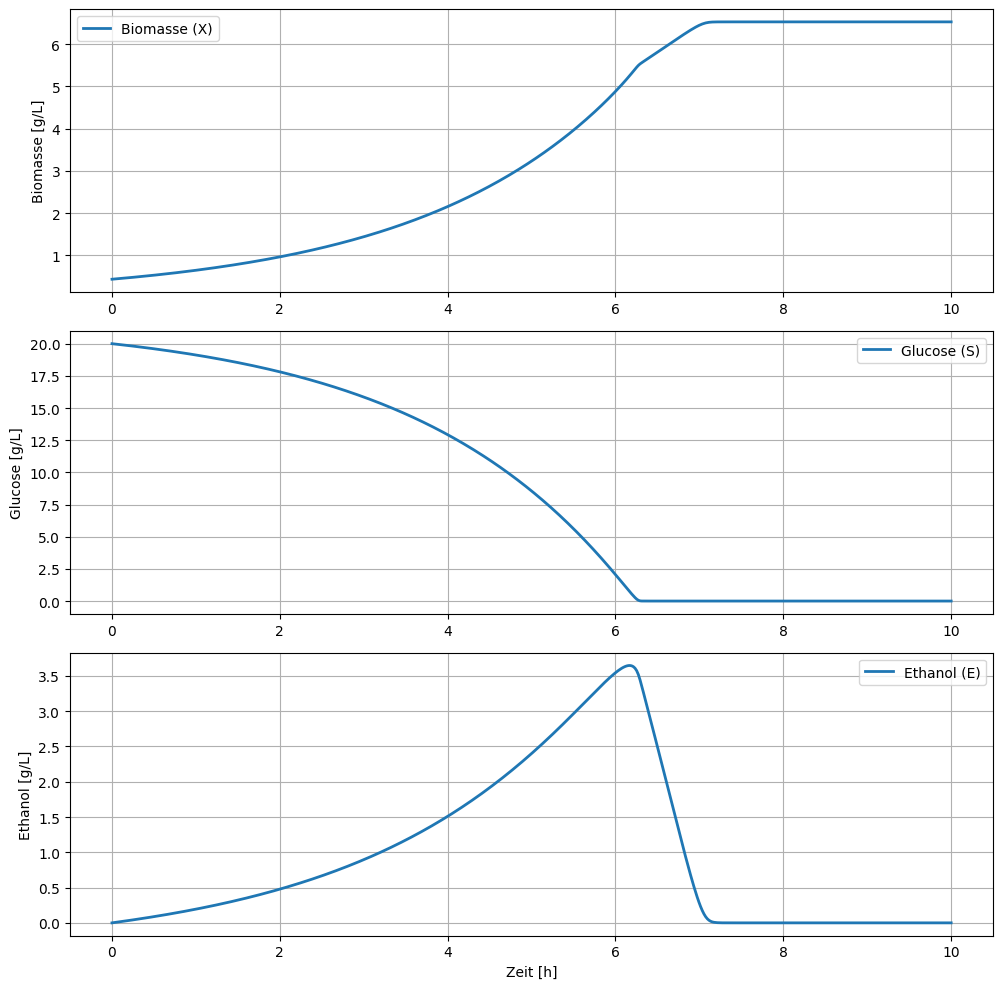

In [ ]:
# Startwerte: [mu_S_max, mu_E_max, K_S, K_E, K_I, Y_XS, Y_ES, Y_XE, X0, S0, E0]
params = [0.5, 0.25, 0.1, 0.2, 0.5, 0.5, 0.45, 0.6]
x0 = np.array([0.25, 20.0, 0.0])

t_span = np.linspace(0, t_end, n_steps)

X_sim = np.zeros(n_steps)
S_sim = np.zeros(n_steps)
E_sim = np.zeros(n_steps)

X_sim[0], S_sim[0], E_sim[0] = x0
x_current = x0

for i in range(1, n_steps):
    res = integrator(x0=x_current, p=params)
    x_current = res['xf'].full().flatten()

    x_current = np.maximum(x_current, 0)

    X_sim[i], S_sim[i], E_sim[i] = x_current

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

axes[0].plot(t_span, X_sim * 0.48, linewidth=2, label='Biomasse (X)')
axes[0].set_ylabel('Biomasse [g/L]')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_span, S_sim, linewidth=2, label='Glucose (S)')
axes[1].set_ylabel('Glucose [g/L]')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t_span, E_sim, linewidth=2, label='Ethanol (E)')
axes[2].set_xlabel('Zeit [h]')
axes[2].set_ylabel('Ethanol [g/L]')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [54]:
# Parameter fitten mit CasADi NLP

# Messdaten vorbereiten
t_data = first_10_hours['hours_since_experiment_created'].values
od_data = first_10_hours['od_reading'].values

# Parameter als Optimierungsvariablen
p_opt = ca.MX.sym('p_opt', 8)  # [mu_S_max, mu_E_max, K_S, K_E, K_I, Y_XS, Y_ES, Y_XE]
x0_opt = ca.MX.sym('x0_opt', 3)  # [X0, S0, E0]

# Simulation über alle Messpunkte
def simulate(params_val, x0_val, t_points):
    X_out = [x0_val[0]]
    x_curr = x0_val
    for i in range(1, len(t_points)):
        dt_i = t_points[i] - t_points[i-1]
        integ_i = ca.integrator('int_i', 'cvodes', dae, {'tf': float(dt_i)})
        res = integ_i(x0=x_curr, p=params_val)
        x_curr = res['xf'].full().flatten()
        x_curr = np.maximum(x_curr, 1e-8)
        X_out.append(x_curr[0])
    return np.array(X_out)

# Objective: Least Squares (OD ~ Biomasse X)
def objective(params_val, x0_val):
    X_sim = simulate(params_val, x0_val, t_data)
    return np.sum((X_sim -  8.4 * od_data)**2)

from scipy.optimize import minimize

def obj_wrapper(theta):
    params_val = theta[:8]
    x0_val = [theta[8], 20.0, theta[9]]
    return objective(params_val, x0_val)

# Startwerte: [mu_S_max, mu_E_max, K_S, K_E, K_I, Y_XS, Y_ES, Y_XE, X0, E0]
theta0 = [0.4, 0.2, 0.1, 0.1, 0.5, 0.5, 0.45, 0.6, 0.25, 0.0]
bounds = [(0.01, 2)]*8 + [(0.01, 1),(0, 5)]

result = minimize(obj_wrapper, theta0, method='L-BFGS-B', bounds=bounds, 
                  options={'maxiter': 50, 'disp': True})

# Ergebnis
params_fit = result.x[:8]
x0_fit = result.x[8:11]
print(f"Fitted params: mu_S_max={params_fit[0]:.3f}, mu_E_max={params_fit[1]:.3f}, "
      f"K_S={params_fit[2]:.3f}, K_E={params_fit[3]:.3f}, K_I={params_fit[4]:.3f}, "
      f"Y_XS={params_fit[5]:.3f}, Y_ES={params_fit[6]:.3f}, Y_XE={params_fit[7]:.3f}")
print(f"Fitted x0: X0={x0_fit[0]:.3f}, E0={x0_fit[2]:.3f}")


/var/folders/tl/5br3rrhd6pvg95k0wtpqcfgm0000gn/T/ipykernel_19339/4239392351.py:40: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(obj_wrapper, theta0, method='L-BFGS-B', bounds=bounds,


Fitted params: mu_S_max=0.645, mu_E_max=0.195, K_S=0.116, K_E=0.221, K_I=0.562, Y_XS=0.393, Y_ES=0.391, Y_XE=0.520


IndexError: index 2 is out of bounds for axis 0 with size 2

In [55]:
# Plot Vergleich
X_fit = simulate(params_fit, x0_fit, t_data)
plt.figure(figsize=(10, 6))
plt.scatter(t_data, od_data, label='OD Messdaten', alpha=0.5)
plt.plot(t_data, X_fit, 'r-', linewidth=2, label='Fitted Model (X)')
plt.xlabel('Zeit [h]')
plt.ylabel('OD / Biomasse')
plt.legend()
plt.grid(True)
plt.title('Parameter Fitting')
plt.show()

RuntimeError: Error in Function::call for 'int_i' [CvodesInterface] at .../casadi/core/function.cpp:1466:
Error in Function::call for 'int_i' [CvodesInterface] at .../casadi/core/function.cpp:362:
.../casadi/core/function_internal.hpp:1728: Input 0 (x0) has mismatching shape. Got 2-by-1. Allowed dimensions, in general, are:
 - The input dimension N-by-M (here 3-by-1)
 - A scalar, i.e. 1-by-1
 - M-by-N if N=1 or M=1 (i.e. a transposed vector)
 - N-by-M1 if K*M1=M for some K (argument repeated horizontally)
 - N-by-P*M, indicating evaluation with multiple arguments (P must be a multiple of 1 for consistency with previous inputs)